In [1]:
run_gridsearch = True
skip_best_model_validation = False
skip_best_model_test = False
verbose = False

GPU_SETTING = -1
NUM_ENSEMBLES = 5
NUM_ENSEMBLES_FINAL = 1  # ensemble count for final training (validation/test)
BASIN = "guerneville"
MODE = "daily"
RUN_LABEL = "CVTEST_V2"
READ_STAMP = "20250815T000000Z"

ADABOOST_ENSEMBLE = False
BOOTSTRAP_MODELS = False

# --- Hyperparameter Selection Method ---
use_cv_for_selection = False  # False = single-split scoring, True = CV-averaged
CV_INTERVAL_LENGTH = 2
CV_VALIDATION_LENGTH = 1
CV_INTERVAL_MONTH = 'October'


In [ ]:
hyperparam_space = {
    "hidden_size": [64, 128],
    "output_dropout": [0.4],
    "seq_length": [90, 120],
    "num_layers": [1],
    "epochs": [100],
    "batch_size": [64],
    "schedule_pairs": [
        ((0.5, 0.25), (0.01, 0.005, 0.001))
    ]
}

In [3]:
import sys
import pandas as pd
import os
import itertools
from pathlib import Path
from tqdm import tqdm
import warnings
from datetime import datetime
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
current_dir = os.getcwd()
print(current_dir)

/Users/canruso/Desktop/UCB-USACE-RR-PROJECT/notebooks/basins/guerneville


In [5]:
library_path = os.path.join('..', '..', '..','..','UCB-USACE-RR-PROJECT')
sys.path.insert(0, library_path)
print(sys.path)

['../../../../UCB-USACE-RR-PROJECT', '/Users/canruso/Desktop/UCB-USACE-RR-PROJECT/notebooks/basins/guerneville', '/Users/canruso/Desktop', '/Users/canruso/miniforge3/envs/ESDL_LSTM/lib/python310.zip', '/Users/canruso/miniforge3/envs/ESDL_LSTM/lib/python3.10', '/Users/canruso/miniforge3/envs/ESDL_LSTM/lib/python3.10/lib-dynload', '', '/Users/canruso/miniforge3/envs/ESDL_LSTM/lib/python3.10/site-packages', '/Users/canruso/miniforge3/envs/ESDL_LSTM/lib/python3.10/site-packages/setuptools/_vendor']


In [6]:
from neuralhydrology.evaluation.metrics import *
from UCB_training.UCB_train import UCB_trainer
from UCB_training.UCB_utils import (fractional_multi_lr, write_paths, to_path_or_list, ensure_output_tree, set_active_context, data_dir, repo_root, get_output_dir, make_run_stamp, get_yaml_path, ctx_for, hparams_exists, save_hparams, load_hparams, runs_latest_path, archive_runs_json, read_csv_artifact, ensure_shared_tree)
from UCB_training.UCB_plotting import (plot_timeseries_comparison, scatter_triptych_pngs_v3, ts_triptych_v3)

In [7]:
current_path = os.getcwd()
library_path = current_path.split('UCB-USACE-RR-PROJECT')[0] + 'UCB-USACE-RR-PROJECT'

In [8]:
RUNS_FILE = str(runs_latest_path(BASIN, MODE, RUN_LABEL))
SHOULD_STAMP = run_gridsearch or not (skip_best_model_validation and skip_best_model_test)
RUN_STAMP = make_run_stamp() if SHOULD_STAMP else None
ACTIVE_STAMP = RUN_STAMP if RUN_STAMP is not None else READ_STAMP

In [9]:
set_active_context(basin=BASIN, resolution=MODE, run_stamp=ACTIVE_STAMP, run_tag=RUN_LABEL, append_stamp_to_filenames=False)
SHARED_FOLDER = ensure_shared_tree(BASIN, MODE)
RUNS_PARENT = SHARED_FOLDER / "runs" / (f"{RUN_LABEL}_{RUN_STAMP}" if RUN_STAMP else RUN_LABEL)

print("NH runs will be written under:")
print(RUNS_PARENT.resolve())

NH runs will be written under:
/Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z


In [10]:
path_to_csv = data_dir()
path_to_yaml = get_yaml_path("guerneville_gage_nlayer")
path_to_physics_data = path_to_csv / "Guerneville_daily_shift.csv"

In [11]:
features_with_physics = [
    "BIG SULPHUR CR ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "DRY CREEK 10 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "EF RUSSIAN 20 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "GREEN VALLEY ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "LAGUNA ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "RUSSIAN 20 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "RUSSIAN 30 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "RUSSIAN 40 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "RUSSIAN 50 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "RUSSIAN 60 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "RUSSIAN 70 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "SANTA ROSA CR 10 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "SANTA ROSA CR 20 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "WF RUSSIAN ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "BIG SULPHUR CR PRECIP-INC SCREENED",
    "DRY CREEK 10 PRECIP-INC SCREENED",
    "EF RUSSIAN 20 PRECIP-INC SCREENED",
    "GREEN VALLEY PRECIP-INC SCREENED",
    "LAGUNA PRECIP-INC SCREENED",
    "RUSSIAN 20 PRECIP-INC SCREENED",
    "RUSSIAN 30 PRECIP-INC SCREENED",
    "RUSSIAN 40 PRECIP-INC SCREENED",
    "RUSSIAN 50 PRECIP-INC SCREENED",
    "RUSSIAN 60 PRECIP-INC SCREENED",
    "RUSSIAN 70 PRECIP-INC SCREENED",
    "SANTA ROSA CR 10 PRECIP-INC SCREENED",
    "SANTA ROSA CR 20 PRECIP-INC SCREENED",
    "WF RUSSIAN PRECIP-INC SCREENED",
    "UKIAH CA HUMIDITY USAF-NOAA",
    "UKIAH CA SOLAR RADIATION USAF-NOAA",
    "UKIAH CA TEMPERATURE USAF-NOAA",
    "UKIAH CA WINDSPEED USAF-NOAA",
    "SANTA ROSA CA HUMIDITY USAF-NOAA",
    "SANTA ROSA CA SOLAR RADIATION USAF-NOAA",
    "SANTA ROSA CA TEMPERATURE USAF-NOAA",
    "SANTA ROSA CA WINDSPEED USAF-NOAA",
    "UKIAH CA FLOW USGS-MERGED",
    "GEYSERVILLE CA FLOW USGS-MERGED",
    "Guerneville Gage FLOW",
    "Big Sulphur Cr ET-POTENTIAL",
    "Big Sulphur Cr FLOW",
    "Big Sulphur Cr FLOW-BASE",
    "Big Sulphur Cr INFILTRATION",
    "Big Sulphur Cr PERC-SOIL",
    "Big Sulphur Cr SATURATION FRACTION",
    "Dry Creek 10 ET-POTENTIAL",
    "Dry Creek 10 FLOW",
    "Dry Creek 10 FLOW-BASE",
    "Dry Creek 10 INFILTRATION",
    "Dry Creek 10 PERC-SOIL",
    "Dry Creek 10 SATURATION FRACTION",
    "Green Valley ET-POTENTIAL",
    "Green Valley FLOW",
    "Green Valley FLOW-BASE",
    "Green Valley INFILTRATION",
    "Green Valley PERC-SOIL",
    "Green Valley SATURATION FRACTION",
    "Laguna ET-POTENTIAL",
    "Laguna FLOW",
    "Laguna FLOW-BASE",
    "Laguna INFILTRATION",
    "Laguna PERC-SOIL",
    "Laguna SATURATION FRACTION",
    "Russian 20 ET-POTENTIAL",
    "Russian 20 FLOW",
    "Russian 20 FLOW-BASE",
    "Russian 20 INFILTRATION",
    "Russian 20 PERC-SOIL",
    "Russian 20 SATURATION FRACTION",
    "Russian 30 ET-POTENTIAL",
    "Russian 30 FLOW",
    "Russian 30 FLOW-BASE",
    "Russian 30 INFILTRATION",
    "Russian 30 PERC-SOIL",
    "Russian 30 SATURATION FRACTION",
    "Russian 40 ET-POTENTIAL",
    "Russian 40 FLOW",
    "Russian 40 FLOW-BASE",
    "Russian 40 INFILTRATION",
    "Russian 40 PERC-SOIL",
    "Russian 40 SATURATION FRACTION",
    "Russian 50 ET-POTENTIAL",
    "Russian 50 FLOW",
    "Russian 50 FLOW-BASE",
    "Russian 50 INFILTRATION",
    "Russian 50 PERC-SOIL",
    "Russian 50 SATURATION FRACTION",
    "Russian 60 ET-POTENTIAL",
    "Russian 60 FLOW",
    "Russian 60 FLOW-BASE",
    "Russian 60 INFILTRATION",
    "Russian 60 PERC-SOIL",
    "Russian 60 SATURATION FRACTION",
    "Russian 70 ET-POTENTIAL",
    "Russian 70 FLOW",
    "Russian 70 FLOW-BASE",
    "Russian 70 INFILTRATION",
    "Russian 70 PERC-SOIL",
    "Russian 70 SATURATION FRACTION",
    "Santa Rosa Cr 10 ET-POTENTIAL",
    "Santa Rosa Cr 10 FLOW",
    "Santa Rosa Cr 10 FLOW-BASE",
    "Santa Rosa Cr 10 INFILTRATION",
    "Santa Rosa Cr 10 PERC-SOIL",
    "Santa Rosa Cr 10 SATURATION FRACTION",
    "Santa Rosa Cr 20 ET-POTENTIAL",
    "Santa Rosa Cr 20 FLOW",
    "Santa Rosa Cr 20 FLOW-BASE",
    "Santa Rosa Cr 20 INFILTRATION",
    "Santa Rosa Cr 20 PERC-SOIL",
    "Santa Rosa Cr 20 SATURATION FRACTION",
    "WF Russian ET-POTENTIAL",
    "WF Russian FLOW",
    "WF Russian FLOW-BASE",
    "WF Russian INFILTRATION",
    "WF Russian PERC-SOIL",
    "WF Russian SATURATION FRACTION"
]

In [12]:
no_physics_results = []
physics_results = []

In [13]:
start_time = datetime.utcnow()
print("Start time:", start_time.strftime("%Y-%m-%d %H:%M:%S"))

Start time: 2026-01-21 22:40:06


In [14]:
import multiprocessing as mp
import itertools
import pandas as pd
from tqdm import tqdm
from UCB_training.grid_search_workers import run_single_experiment_nophysics, run_single_experiment_physics

print("run_gridsearch =", run_gridsearch)
print("hparams_exists =", hparams_exists(BASIN, MODE, RUN_LABEL))

hyperparam_names = list(hyperparam_space.keys())
total_iters = 1
for name in hyperparam_names:
    total_iters *= len(hyperparam_space[name])

if run_gridsearch or not hparams_exists(BASIN, MODE, RUN_LABEL):
    all_combinations = list(itertools.product(*[hyperparam_space[hp] for hp in hyperparam_names]))
    num_cores = max(1, mp.cpu_count() - 1)
    print(f"\n[GRID SEARCH] Spawning {num_cores} workers\n")

    # NO PHYSICS GRID SEARCH
    task_args_no = [
        (idx, comb, hyperparam_names, path_to_csv, path_to_yaml,
         GPU_SETTING, RUNS_PARENT, RUN_LABEL, RUN_STAMP, verbose,
         UCB_trainer, fractional_multi_lr, NUM_ENSEMBLES, BOOTSTRAP_MODELS, ADABOOST_ENSEMBLE,
         False, False, use_cv_for_selection, CV_INTERVAL_MONTH, CV_INTERVAL_LENGTH, CV_VALIDATION_LENGTH)
        for idx, comb in enumerate(all_combinations)
    ]
    with mp.Pool(processes=num_cores) as pool:
        no_physics_results = list(tqdm(
            pool.imap(run_single_experiment_nophysics, task_args_no),
            total=len(all_combinations), desc="Grid No-Physics", unit="it", ncols=60, ascii=True))
    df_no_physics = pd.DataFrame(no_physics_results)
    df_no_physics.sort_values(by="NSE", ascending=False, inplace=True)
    df_no_physics.reset_index(drop=True, inplace=True)
    print("\n\u2713 No-physics grid complete\n")

    # PHYSICS GRID SEARCH
    task_args_phys = [
        (idx, comb, hyperparam_names, path_to_csv, path_to_yaml,
         GPU_SETTING, RUNS_PARENT, RUN_LABEL, RUN_STAMP, verbose,
         UCB_trainer, fractional_multi_lr, NUM_ENSEMBLES, BOOTSTRAP_MODELS, ADABOOST_ENSEMBLE,
         features_with_physics, path_to_physics_data,
         False, False, use_cv_for_selection, CV_INTERVAL_MONTH, CV_INTERVAL_LENGTH, CV_VALIDATION_LENGTH)
        for idx, comb in enumerate(all_combinations)
    ]
    with mp.Pool(processes=num_cores) as pool:
        physics_results = list(tqdm(
            pool.imap(run_single_experiment_physics, task_args_phys),
            total=len(all_combinations), desc="Grid Physics", unit="it", ncols=60, ascii=True))
    df_physics = pd.DataFrame(physics_results)
    df_physics.sort_values(by="NSE", ascending=False, inplace=True)
    df_physics.reset_index(drop=True, inplace=True)
    print("\n\u2713 Physics grid complete\n")

    # save best params
    best_no_phys = df_no_physics.iloc[0].to_dict()
    best_phys = df_physics.iloc[0].to_dict()
    best_no_phys["model_type"] = "no_physics"
    best_phys["model_type"] = "physics"
    best_params_df = pd.DataFrame([best_no_phys, best_phys])
    save_hparams(best_df=best_params_df, basin=BASIN, mode=MODE, label=RUN_LABEL, run_stamp=RUN_STAMP, df_no=df_no_physics, df_phys=df_physics)
else:
    print("Skipping grid search!")

print("run_gridsearch =", run_gridsearch)
print("hparams_exists =", hparams_exists(BASIN, MODE, RUN_LABEL))

Grid-Search:   0%|                   | 0/54 [00:00<?, ?it/s]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_014006/fold_01/testing_run_2201_014006/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_014006/fold_02/testing_run_2201_014012/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_014006/fold_03/testing_run_2201_014020/loss_curves.png


Grid-Search:   2%|2          | 1/54 [00:39<34:41, 39.28s/it]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_014006/fold_04/testing_run_2201_014031/loss_curves.png
{'avg NSE': 0.5842065364122391, 'avg MSE': 13699190.21875, 'avg RMSE': 3284.892810147162, 'avg KGE': 0.5887650724544964, 'avg Alpha-NSE': 1.009941710733887, 'avg Beta-KGE': 1.1103314310312271, 'avg Beta-NSE': 0.06198809648357837, 'avg Pearson-r': 0.8340046201407598, 'avg FHV': -18.026000959798694, 'avg FMS': 524.115063103525, 'avg FLV': -886.0988473531884, 'avg Peak-Timing': 0.625, 'avg Peak-MAPE': 44.03578154742718}
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_014045/fold_01/testing_run_2201_014045/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_014045/fold_0

Grid-Search:   4%|4          | 2/54 [01:12<30:42, 35.43s/it]

...

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_031555/fold_04/testing_run_2201_031944/loss_curves.png
{'avg NSE': 0.6655980832874775, 'avg MSE': 13955637.625, 'avg RMSE': 3075.553378570529, 'avg KGE': 0.6542315394611421, 'avg Alpha-NSE': 0.9064233755220645, 'avg Beta-KGE': 1.052072823047638, 'avg Beta-NSE': 0.038337621605566585, 'avg Pearson-r': 0.8473970573836962, 'avg FHV': -25.909401336684823, 'avg FMS': 341.35908670185074, 'avg FLV': -1780.1276937066496, 'avg Peak-Timing': 0.5, 'avg Peak-MAPE': 48.18951673805714}
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_032225/fold_01/testing_run_2201_032225/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_032225/fold_0

Grid-Search:  98%|######8| 53/54 [1:47:20<04:21, 261.70s/it]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_032225/fold_04/testing_run_2201_032522/loss_curves.png
{'avg NSE': 0.6178852468729019, 'avg MSE': 15281603.5, 'avg RMSE': 3252.985189611063, 'avg KGE': 0.6304397657038087, 'avg Alpha-NSE': 0.9035244991255984, 'avg Beta-KGE': 1.1116936057806015, 'avg Beta-NSE': 0.05588204354042747, 'avg Pearson-r': 0.8236207421914586, 'avg FHV': -27.918693074025214, 'avg FMS': 346.9711989501049, 'avg FLV': -1415.0299277124147, 'avg Peak-Timing': 0.75, 'avg Peak-MAPE': 51.91737487912178}
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_032726/fold_01/testing_run_2201_032726/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_032726/fold_02/

Grid-Search: 100%|#######| 54/54 [1:51:46<00:00, 124.20s/it]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_032726/fold_04/testing_run_2201_033003/loss_curves.png
{'avg NSE': 0.5657306611537933, 'avg MSE': 15859863.09375, 'avg RMSE': 3421.4800856950574, 'avg KGE': 0.6716542178874, 'avg Alpha-NSE': 0.9121486317055674, 'avg Beta-KGE': 1.0278169214725494, 'avg Beta-NSE': 0.020866170135179198, 'avg Pearson-r': 0.783307027822031, 'avg FHV': -33.01983214914799, 'avg FMS': 737.9551378302684, 'avg FLV': -108.42587599482127, 'avg Peak-Timing': 0.5, 'avg Peak-MAPE': 54.03593108057976}


In [15]:
# Physics grid search merged into cell above

Grid-Search:   0%|                   | 0/54 [00:00<?, ?it/s]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_033153/fold_01/testing_run_2201_033153/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_033153/fold_02/testing_run_2201_033159/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_033153/fold_03/testing_run_2201_033209/loss_curves.png


Grid-Search:   2%|2          | 1/54 [00:45<40:14, 45.55s/it]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_033153/fold_04/testing_run_2201_033222/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_033238/fold_01/testing_run_2201_033238/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_033238/fold_02/testing_run_2201_033245/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_033238/fold_03/testing_run_2201_033253/loss_curves.png


Grid-Search:   4%|4          | 2/54 [01:25<36:50, 42.50s/it]

...

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_051156/fold_04/testing_run_2201_051535/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_051808/fold_01/testing_run_2201_051808/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_051808/fold_02/testing_run_2201_051836/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_051808/fold_03/testing_run_2201_051935/loss_curves.png


Grid-Search:  98%|######8| 53/54 [1:51:18<04:21, 261.32s/it]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_051808/fold_04/testing_run_2201_052107/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_052311/fold_01/testing_run_2201_052311/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_052311/fold_02/testing_run_2201_052337/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_052311/fold_03/testing_run_2201_052430/loss_curves.png


Grid-Search: 100%|#######| 54/54 [1:55:45<00:00, 128.62s/it]

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/cross_validation_2201_052311/fold_04/testing_run_2201_052552/loss_curves.png


In [16]:
try:
    if run_gridsearch:
        print("\n[INFO] Using best_params_df from the just-completed grid search (ignoring READ_STAMP).")
    else:
        print("\nLoading best hyperparams from CSV...")
        best_params_df = load_hparams(BASIN, MODE, RUN_LABEL, stamp=READ_STAMP)
except FileNotFoundError as e:
    raise SystemExit(f"[ERROR] {e}  (Set run_gridsearch=True to generate it.)")

best_no_phys = best_params_df.query("model_type == 'no_physics'").iloc[0].to_dict()
best_phys = best_params_df.query("model_type == 'physics'").iloc[0].to_dict()

best_no_physics_params = {}
j = 0
while j < len(hyperparam_names):
    name = hyperparam_names[j]
    if name == "output_dropout":
        best_no_physics_params[name] = float(best_no_phys[name])
        j += 1

    elif name == "seq_length":
        best_no_physics_params["seq_length"] = int(best_no_phys["seq_length"])
        j += 1

    elif name == "schedule_pairs":
        j += 1

    else:
        best_no_physics_params[name] = int(best_no_phys[name])
        j += 1

if "learning_rate" in best_no_phys and pd.notna(best_no_phys["learning_rate"]):
    best_no_physics_params["learning_rate"] = eval(str(best_no_phys["learning_rate"]))

elif "schedule_pairs" in best_no_phys and pd.notna(best_no_phys["schedule_pairs"]):
    sp = best_no_phys["schedule_pairs"]
    if isinstance(sp, str):
        sp = eval(sp)
    fractions, rates = sp
    best_no_physics_params["learning_rate"] = fractional_multi_lr(
        epochs=int(best_no_physics_params["epochs"]),
        fractions=list(fractions),
        lrs=list(rates))

else:
    best_no_physics_params["learning_rate"] = {0: 0.01, 30: 0.005, 40: 0.001}

best_physics_params = {}
j = 0
while j < len(hyperparam_names):
    name = hyperparam_names[j]
    if name == "output_dropout":
        best_physics_params[name] = float(best_phys[name])
        j += 1

    elif name == "seq_length":
        best_physics_params["seq_length"] = int(best_phys["seq_length"])
        j += 1

    elif name == "schedule_pairs":
        j += 1

    else:
        best_physics_params[name] = int(best_phys[name])
        j += 1

if "learning_rate" in best_phys and pd.notna(best_phys["learning_rate"]):
    best_physics_params["learning_rate"] = eval(str(best_phys["learning_rate"]))

elif "schedule_pairs" in best_phys and pd.notna(best_phys["schedule_pairs"]):
    sp = best_phys["schedule_pairs"]
    if isinstance(sp, str):
        sp = eval(sp)
    fractions, rates = sp
    best_physics_params["learning_rate"] = fractional_multi_lr(
        epochs=int(best_physics_params["epochs"]),
        fractions=list(fractions),
        lrs=list(rates))

else:
    best_physics_params["learning_rate"] = {0: 0.01, 30: 0.005, 40: 0.001}

print("Loaded best hyperparams from CSV:")
print("Best NO-PHYS:", best_no_physics_params)
print("Best PHYS:", best_physics_params)


[INFO] Using best_params_df from the just-completed grid search (ignoring READ_STAMP).
Loaded best hyperparams from CSV:
Best NO-PHYS: {'hidden_size': 128, 'output_dropout': 0.4, 'seq_length': 90, 'num_layers': 1, 'epochs': 48, 'batch_size': 64, 'learning_rate': {0: 0.01, 24: 0.005, 36: 0.001}}
Best PHYS: {'hidden_size': 256, 'output_dropout': 0.4, 'seq_length': 90, 'num_layers': 1, 'epochs': 48, 'batch_size': 64, 'learning_rate': {0: 0.01, 24: 0.005, 36: 0.001}}


### Re-run validation with best hyperparameters

In [17]:
if not skip_best_model_validation:
    lstmNoPhysicsValBest = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_no_physics_params,
        input_features=None,
        physics_informed=False,
        physics_data_file=None,
        hourly=False,
        extend_train_period=False,
        gpu=GPU_SETTING,
        # num_ensemble_members = NUM_ENSEMBLES_FINAL,
        verbose = verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP)
    
    lstmNoPhysicsValBest.train()
    no_physics_val_csv, no_physics_val_metrics = lstmNoPhysicsValBest.results()
    no_physics_val_metrics

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/testing_run_2201_052738/loss_curves.png


In [18]:
if not skip_best_model_validation:
    lstmPhysicsValBest = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_physics_params,
        input_features=features_with_physics,
        physics_informed=True,
        physics_data_file=path_to_physics_data,
        hourly=False,
        extend_train_period=False,
        gpu=GPU_SETTING,
        # num_ensemble_members = NUM_ENSEMBLES_FINAL,
        verbose = verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP)
    
    lstmPhysicsValBest.train()
    physics_val_csv, physics_val_metrics = lstmPhysicsValBest.results()
    physics_val_metrics

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/testing_run_2201_052833/loss_curves.png


HMS
  NSE = 0.882
  PBIAS = -5.314
LSTM
  NSE = 0.807
  PBIAS = 4.026
PILSTM
  NSE = 0.835
  PBIAS = -3.020


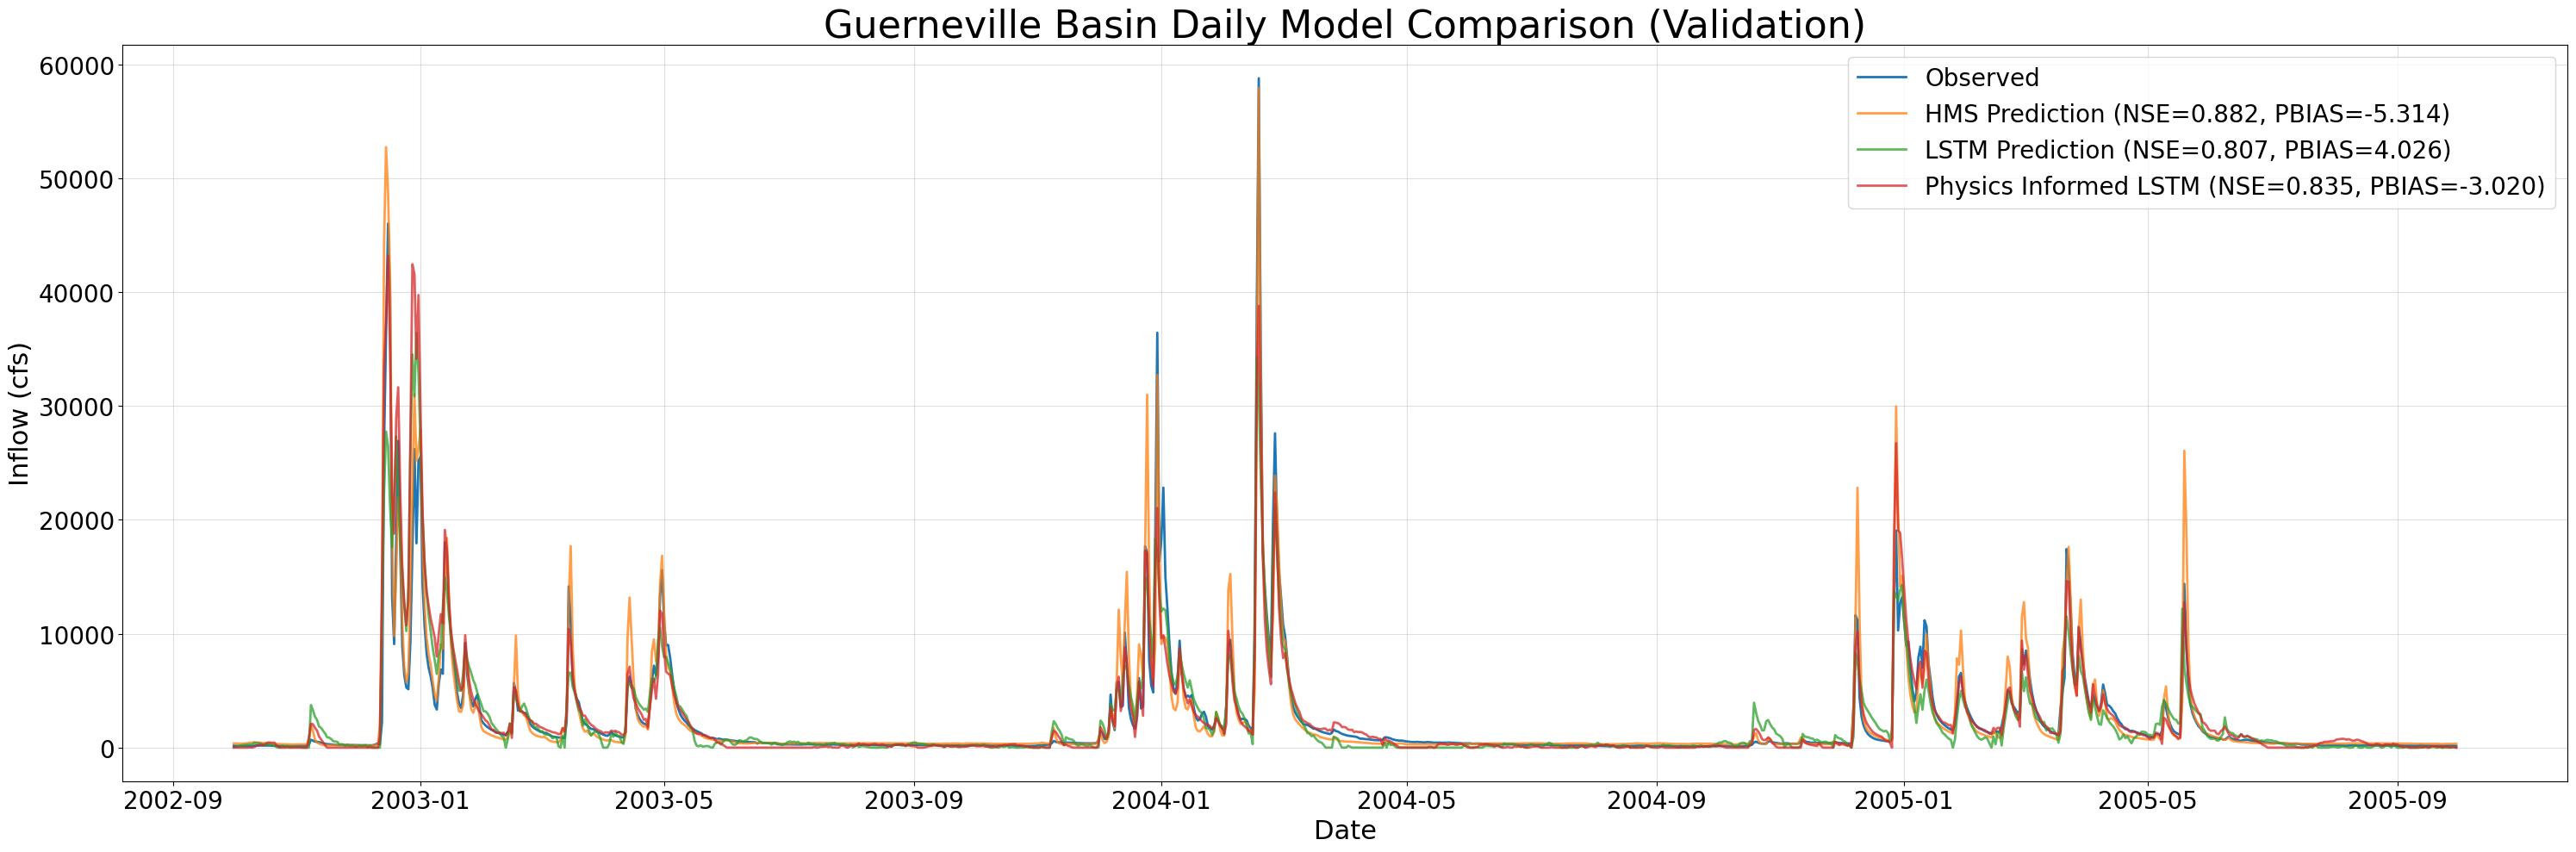

In [19]:
if not skip_best_model_validation:
    plot_timeseries_comparison(source=(no_physics_val_csv, physics_val_csv, path_to_physics_data), title="Guerneville Basin Daily Model Comparison (Validation)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="guerneville_daily_val_metrics.csv", ts_out="guerneville_daily_val_combined_ts.csv", fig_out="guerneville_daily_val_model_comparison.png", legend_font=20, axis_font=22)
else:
    combined_df_val = read_csv_artifact("guerneville_daily_val_combined_ts.csv", kind="csv", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)           
    plot_timeseries_comparison(source=combined_df_val, title="Guerneville Basin Daily Model Comparison (Validation)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="guerneville_daily_val_metrics.csv", ts_out="guerneville_daily_val_combined_ts.csv", fig_out="guerneville_daily_val_model_comparison.png", legend_font=20, axis_font=22)

In [20]:
if skip_best_model_validation:
    val_metrics = read_csv_artifact("guerneville_daily_val_metrics.csv", kind="metrics", period="validation", index_col=0, stamp = READ_STAMP, run_label = RUN_LABEL)
    print(val_metrics)

### Re-run testing with best hyperparameters

In [21]:
if not skip_best_model_test:
    lstmNoPhysicsExtBest = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_no_physics_params,
        input_features=None,
        physics_informed=False,
        physics_data_file=None,
        hourly=False,
        extend_train_period=True,  
        gpu=GPU_SETTING,
        num_ensemble_members = NUM_ENSEMBLES_FINAL,
        verbose = verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP)
    
    lstmNoPhysicsExtBest.train()
    no_physics_test_csv, no_physics_test_metrics = lstmNoPhysicsExtBest.results('test')
    no_physics_test_metrics

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/testing_run_2201_053032/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/testing_run_2201_053032/testing_run_2201_053147/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/testing_run_2201_053032/testing_run_2201_053147/testing_run_2201_053304/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/testing_run_2201_053032/testing_run_2201_053147/testing_run_2201_053304/testing_run_2201_053421/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/testing_run_2201_053032/testing_run_2201_05314

100%|██████████| 1/1 [00:00<00:00, 158.71it/s]


In [22]:
if not skip_best_model_test:
    lstmPhysicsExtBest = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_physics_params,
        input_features=features_with_physics,
        physics_informed=True,
        physics_data_file=path_to_physics_data,
        hourly=False,
        extend_train_period=True,
        gpu=GPU_SETTING,
        num_ensemble_members = NUM_ENSEMBLES_FINAL,
        verbose = verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP)
    
    lstmPhysicsExtBest.train()
    physics_test_csv, physics_test_metrics = lstmPhysicsExtBest.results('test')
    physics_test_metrics

Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/testing_run_2201_053717/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/testing_run_2201_053717/testing_run_2201_054014/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/testing_run_2201_053717/testing_run_2201_054014/testing_run_2201_054308/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/testing_run_2201_053717/testing_run_2201_054014/testing_run_2201_054308/testing_run_2201_054555/loss_curves.png
Loss curve saved to: /Users/canruso/Desktop/UCB-USACE-RR-PROJECT/outputs/guerneville/daily_shared/runs/CVTEST_V2_20260121T224006Z/testing_run_2201_053717/testing_run_2201_05401

100%|██████████| 1/1 [00:00<00:00, 160.87it/s]


HMS
  NSE = 0.850
  PBIAS = -13.709
LSTM
  NSE = 0.852
  PBIAS = -12.269
PILSTM
  NSE = 0.884
  PBIAS = -13.272


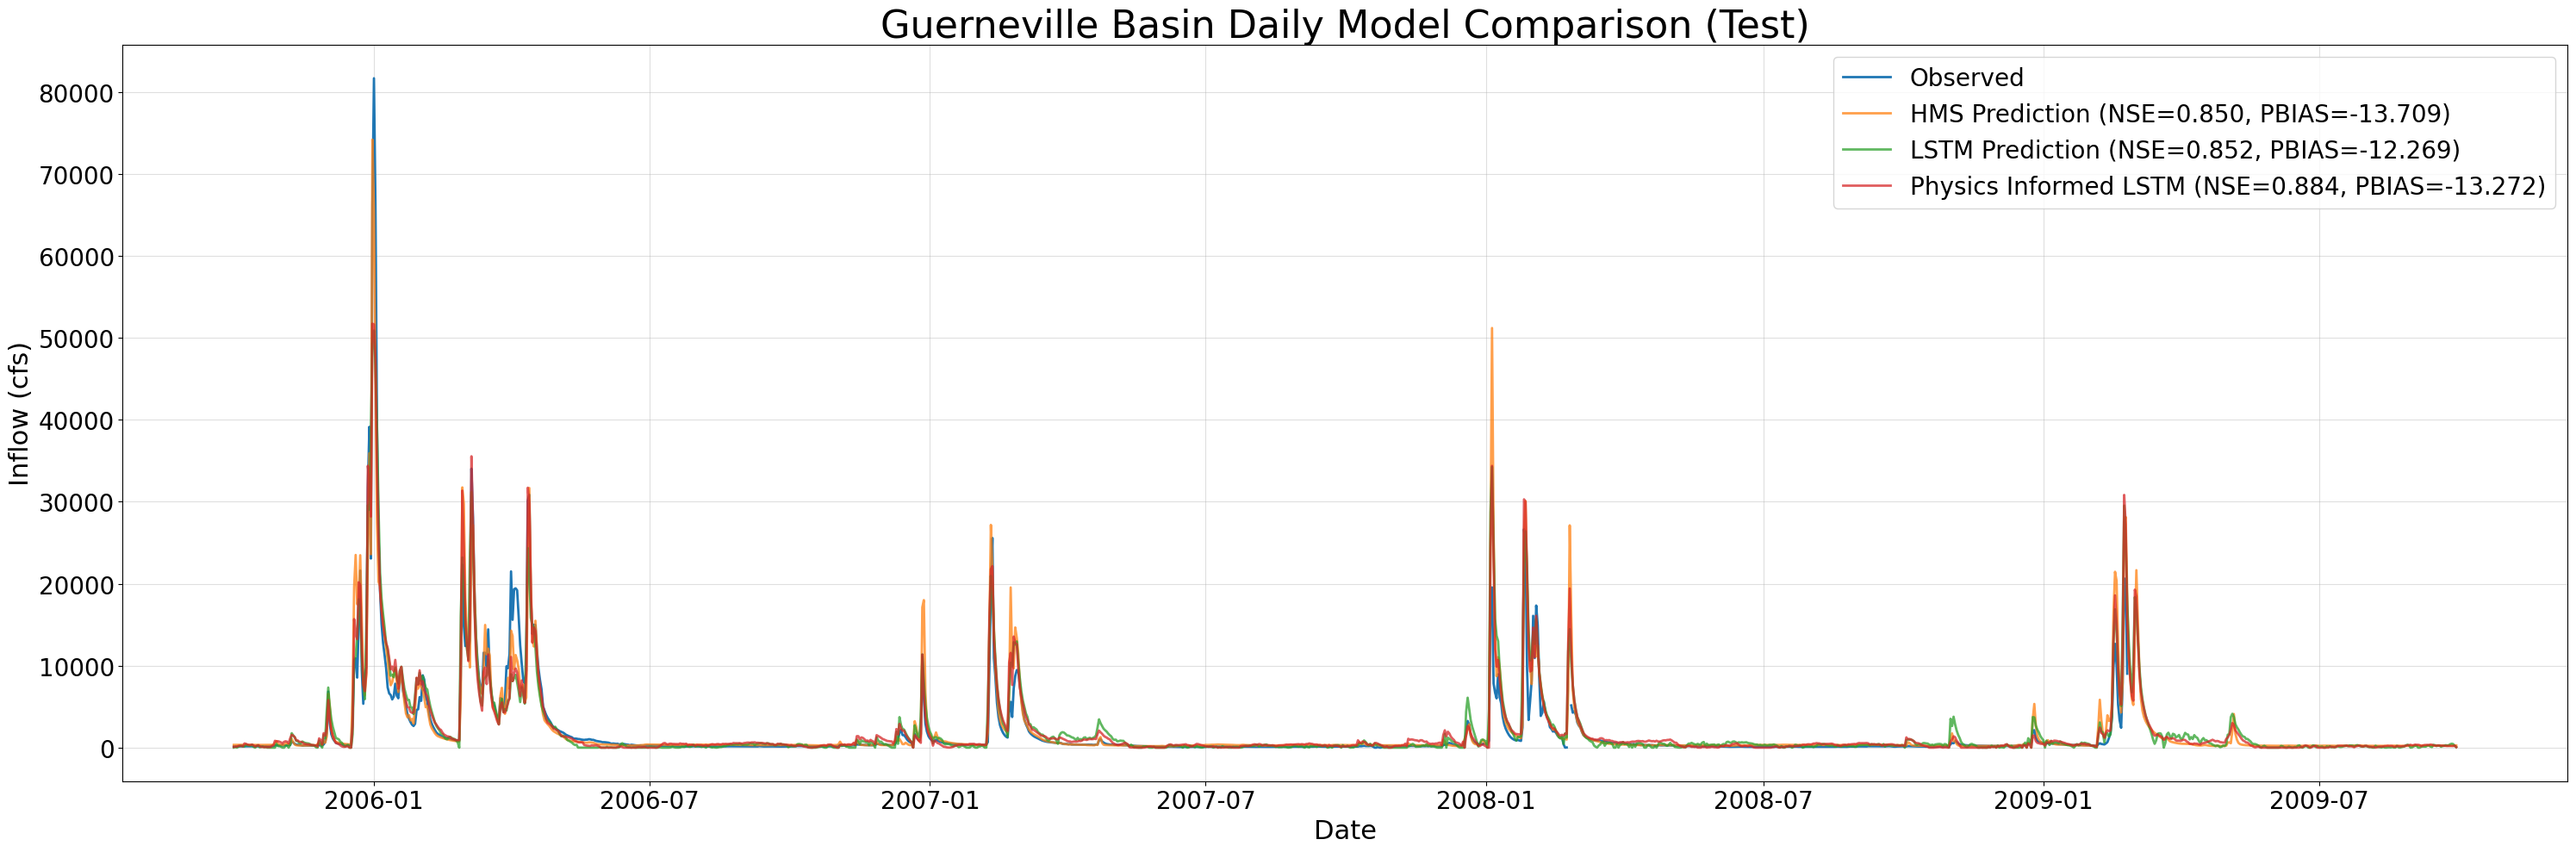

In [23]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Guerneville Basin Daily Model Comparison (Test)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="guerneville_daily_test_metrics.csv", ts_out="guerneville_daily_test_combined_ts.csv", fig_out="guerneville_daily_test_model_comparison.png", legend_font=20, axis_font=22)
else:
    combined_df = read_csv_artifact("guerneville_daily_test_combined_ts.csv", kind="csv", period="test", stamp = READ_STAMP, run_label = RUN_LABEL)
    plot_timeseries_comparison(source=combined_df, title="Guerneville Basin Daily Model Comparison (Test)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="guerneville_daily_test_metrics.csv", ts_out="guerneville_daily_test_combined_ts.csv", fig_out="guerneville_daily_test_model_comparison.png", legend_font=20, axis_font=22)

In [24]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Guerneville Basin Daily Model Comparison", backend="plotly", metrics=["NSE", "PBIAS"], metrics_out="guerneville_daily_test_metrics.csv", ts_out="guerneville_daily_test_combined_ts.csv", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Guerneville Basin Daily Model Comparison", backend="plotly", metrics=["NSE", "PBIAS"], metrics_out="guerneville_daily_test_metrics.csv", ts_out="guerneville_daily_test_combined_ts.csv", legend_font=12, axis_font=22)

HMS
  NSE = 0.850
  PBIAS = -13.709
LSTM
  NSE = 0.852
  PBIAS = -12.269
PILSTM
  NSE = 0.884
  PBIAS = -13.272


In [25]:
test_metrics = read_csv_artifact("guerneville_daily_test_metrics.csv", kind="metrics", period="test", index_col=0, stamp = READ_STAMP, run_label = RUN_LABEL)
print(test_metrics)

                      HMS          LSTM        PILSTM
NSE          8.499148e-01  8.516517e-01  8.839854e-01
MSE          4.623214e+06  4.569709e+06  3.573704e+06
RMSE         2.150166e+03  2.137688e+03  1.890424e+03
KGE          8.430313e-01  8.410749e-01  8.460035e-01
Alpha-NSE    1.026757e+00  9.335631e-01  9.483939e-01
Beta-KGE     1.137092e+00  1.122687e+00  1.132723e+00
Beta-NSE     4.800381e-02  4.295962e-02  4.647372e-02
Pearson-r    9.283838e-01  9.238997e-01  9.413790e-01
FHV          2.575219e+00 -5.152468e+00 -5.477823e-01
FMS         -2.409063e+01  2.484081e+01 -9.491267e+00
FLV          9.758516e+01  4.724026e+01  2.565911e+01
Peak-Timing  7.500000e-01  7.500000e-01  5.000000e-01
Peak-MAPE    1.465164e+01  3.077579e+01  2.325331e+01
PBIAS       -1.370924e+01 -1.226869e+01 -1.327227e+01


In [ ]:
if not skip_best_model_validation:
    write_paths("no_physics_val", lstmNoPhysicsValBest, filename = RUNS_FILE)
    write_paths("physics_val", lstmPhysicsValBest, filename = RUNS_FILE)

if not skip_best_model_test:
    write_paths("no_physics", lstmNoPhysicsExtBest, filename = RUNS_FILE)
    write_paths("physics", lstmPhysicsExtBest, filename = RUNS_FILE)
    archived_path = archive_runs_json(Path(RUNS_FILE), BASIN, MODE, RUN_LABEL, RUN_STAMP)

In [27]:
end_time = datetime.utcnow()
print("\nEnd time:", end_time.strftime("%Y-%m-%d %H:%M:%S"))
print("Total time:", end_time - start_time)


End time: 2026-01-22 02:52:09
Total time: 4:12:02.965701


##### Additional Plots

In [28]:
if skip_best_model_validation:
    combined_df_val = read_csv_artifact("guerneville_daily_val_combined_ts.csv", kind="csv", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)
if skip_best_model_test:
    combined_df = read_csv_artifact("guerneville_daily_test_combined_ts.csv", kind="csv", period="test", stamp = READ_STAMP, run_label = RUN_LABEL)

In [29]:
metric_list = ["NSE", "PBIAS"]

wettest_start_val = "2003-10-01"
wettest_end_val = "2004-09-30"
dryest_start_val = "2004-10-01"
dryest_end_val = "2005-09-30"
wettest_start_test = "2005-10-01"
wettest_end_test = "2006-09-30"
dryest_start_test = "2008-10-01"
dryest_end_test = "2009-09-30"

HMS
  NSE = 0.882
  PBIAS = -5.314
LSTM
  NSE = 0.807
  PBIAS = 4.026
PILSTM
  NSE = 0.835
  PBIAS = -3.020


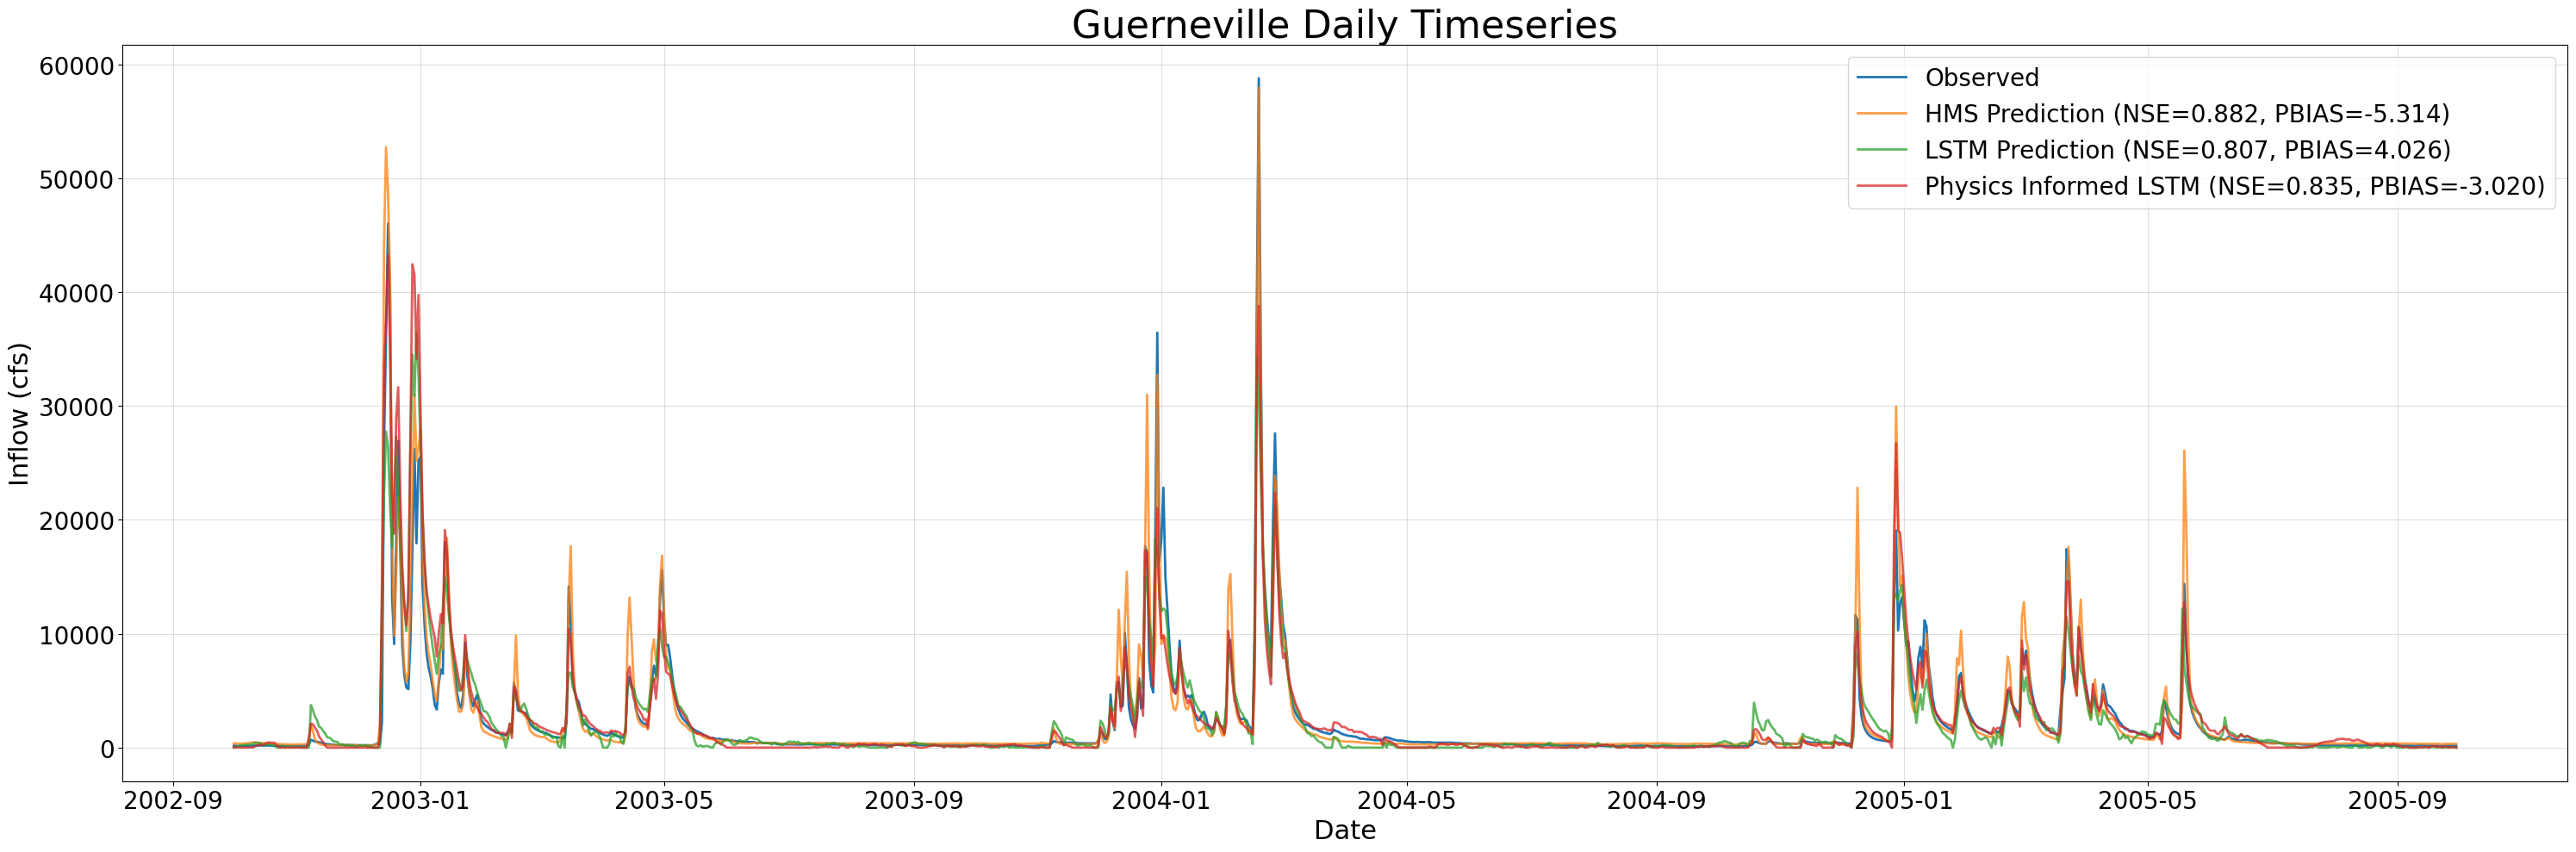

In [30]:
if not skip_best_model_validation: 
    plot_timeseries_comparison(source=(no_physics_val_csv, physics_val_csv, path_to_physics_data), title="Guerneville Daily Timeseries", backend="mpl", metrics=metric_list, metrics_out="guerneville_daily_val_metrics.csv", ts_out="guerneville_daily_val_combined_ts.csv", fig_out="guerneville_daily_val_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_val, title="Guerneville Daily Timeseries", backend="mpl", metrics=metric_list, metrics_out="guerneville_daily_val_metrics.csv", ts_out="guerneville_daily_val_combined_ts.csv", fig_out="guerneville_daily_val_model_comparison.png", legend_font=20, axis_font=22)

HMS
  NSE = 0.850
  PBIAS = -13.709
LSTM
  NSE = 0.852
  PBIAS = -12.269
PILSTM
  NSE = 0.884
  PBIAS = -13.272


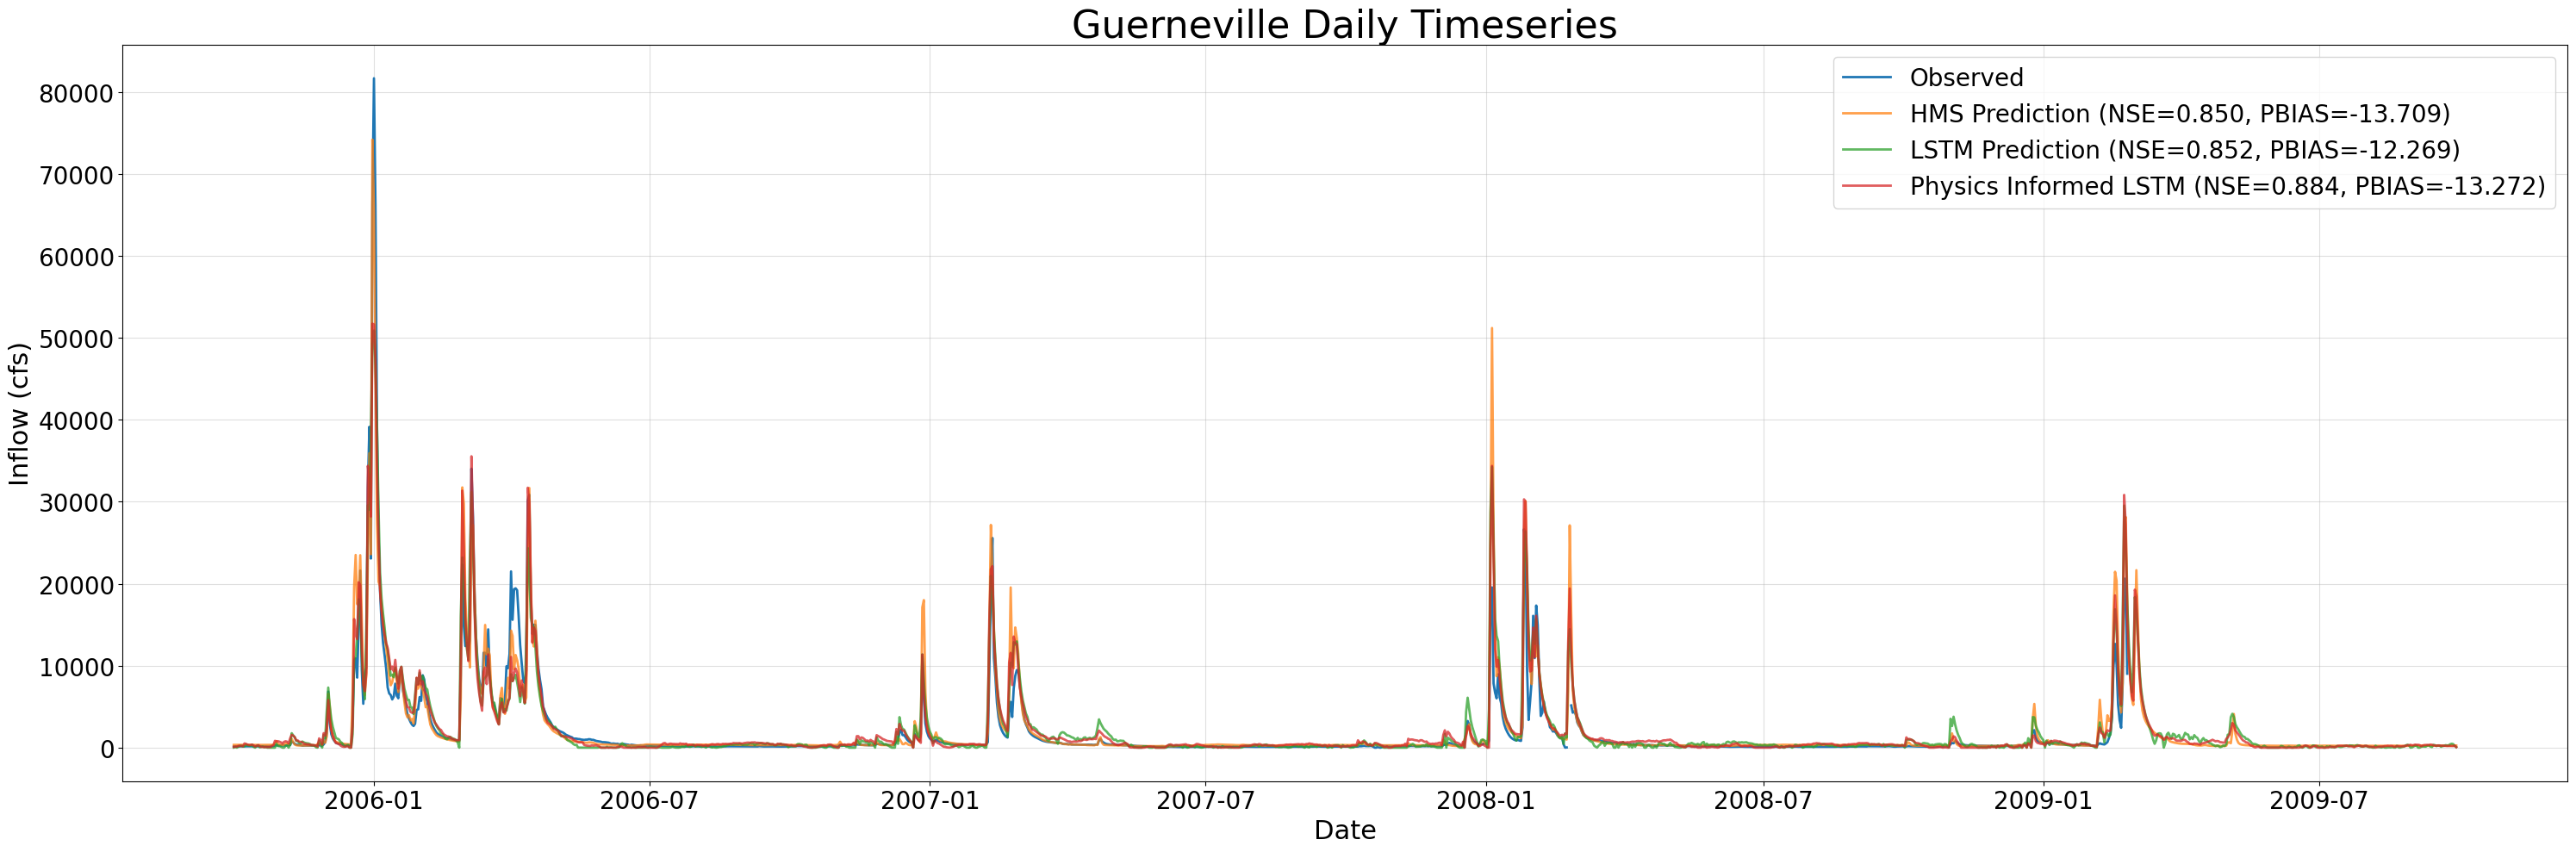

In [31]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Guerneville Daily Timeseries", backend="mpl", metrics=metric_list, metrics_out="guerneville_daily_test_metrics.csv", ts_out="guerneville_daily_test_combined_ts.csv", fig_out="guerneville_daily_test_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Guerneville Daily Timeseries", backend="mpl", metrics=metric_list, metrics_out="guerneville_daily_test_metrics.csv", ts_out="guerneville_daily_test_combined_ts.csv", fig_out="guerneville_daily_test_model_comparison.png", legend_font=20, axis_font=22)

In [32]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Guerneville Daily Timeseries – Interactive", backend="plotly", metrics=metric_list, metrics_out="guerneville_daily_test_metrics.csv", ts_out="guerneville_daily_test_combined_ts.csv", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Guerneville Daily Timeseries – Interactive", backend="plotly", metrics=metric_list, metrics_out="guerneville_daily_test_metrics.csv", ts_out="guerneville_daily_test_combined_ts.csv", legend_font=12, axis_font=22)

HMS
  NSE = 0.850
  PBIAS = -13.709
LSTM
  NSE = 0.852
  PBIAS = -12.269
PILSTM
  NSE = 0.884
  PBIAS = -13.272


##### Wettest Year Performance

HMS
  NSE = 0.908
  PBIAS = 3.188
LSTM
  NSE = 0.860
  PBIAS = 15.974
PILSTM
  NSE = 0.898
  PBIAS = 17.306


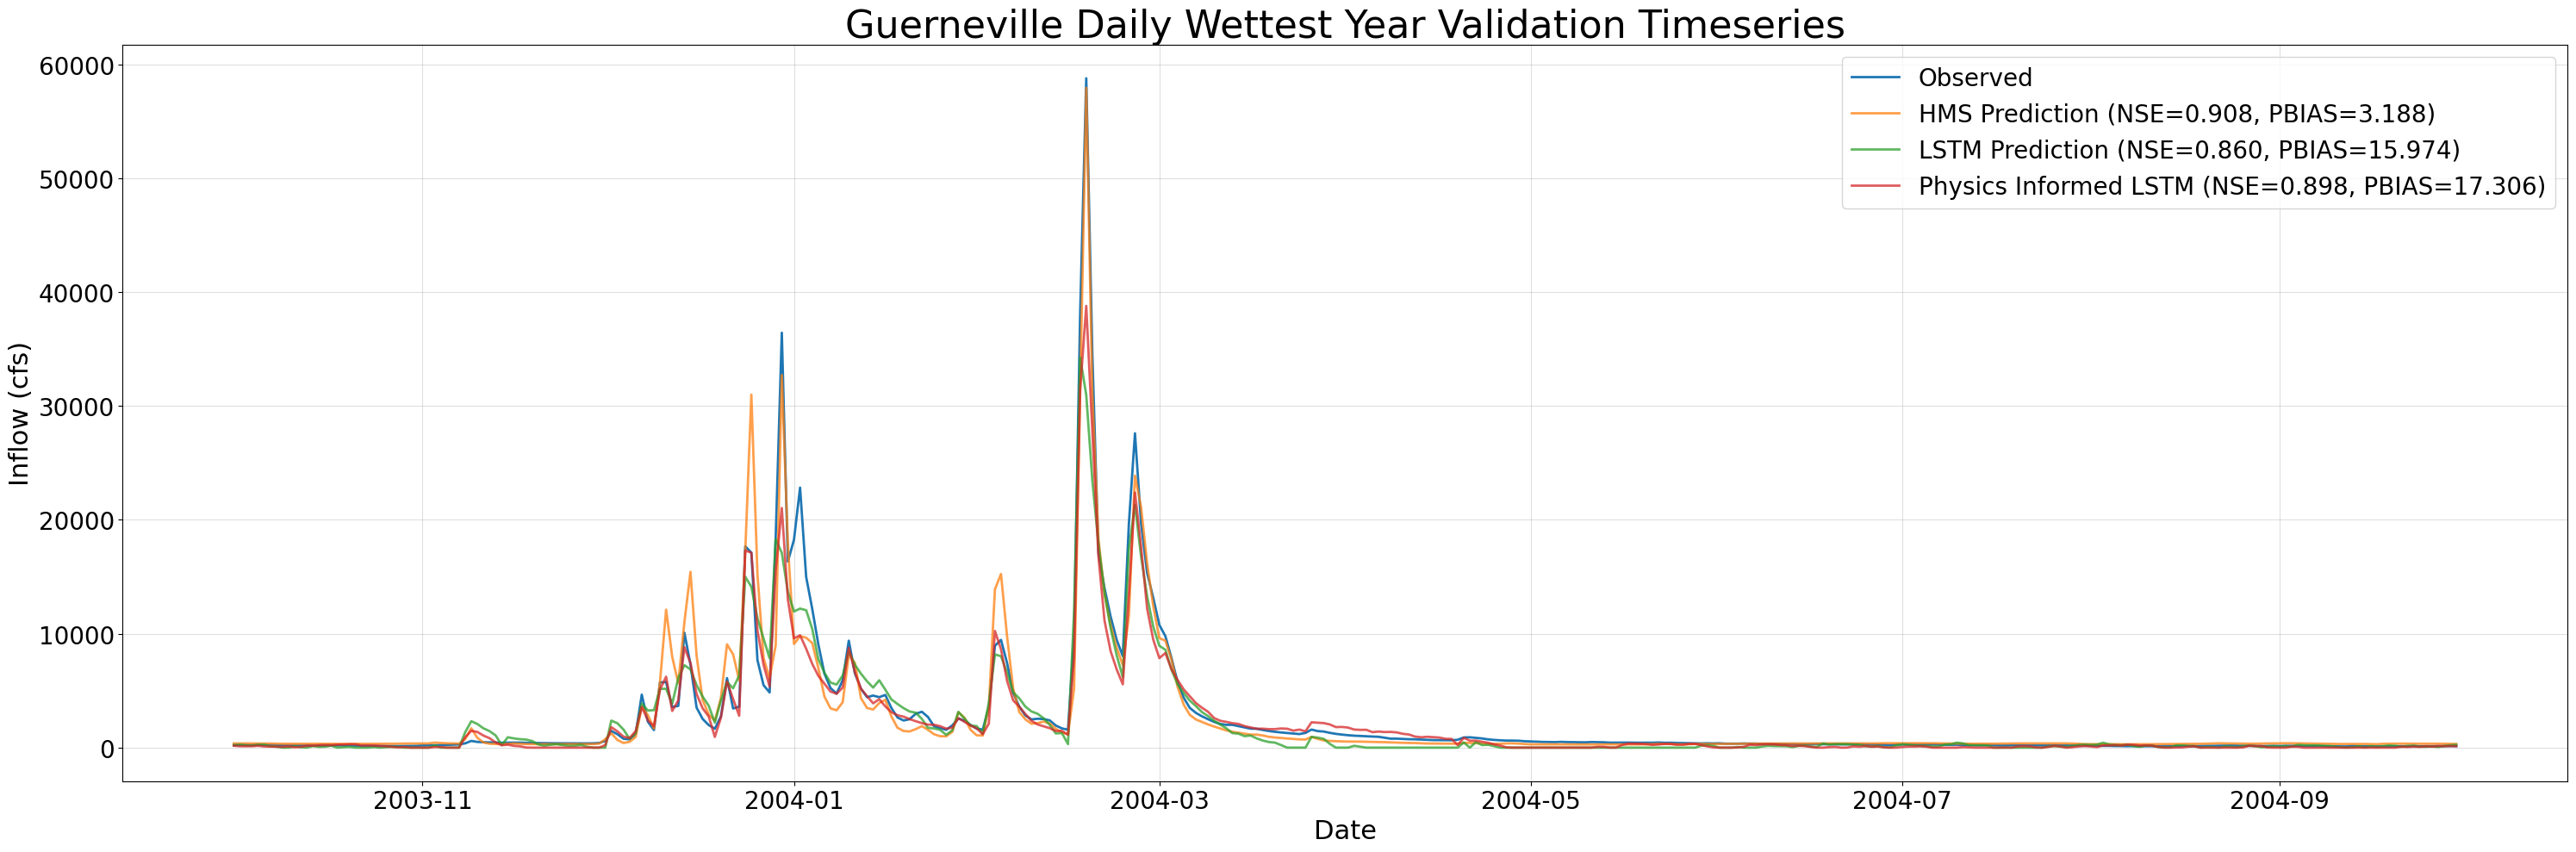

In [33]:
if not skip_best_model_validation:
    plot_timeseries_comparison(source=(no_physics_val_csv, physics_val_csv, path_to_physics_data), title="Guerneville Daily Wettest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_val, end_date=wettest_end_val, metrics_out="guerneville_daily_val_wet_metrics.csv", ts_out="guerneville_daily_val_wet_combined_ts.csv", fig_out="guerneville_daily_val_wet_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_val, title="Guerneville Daily Wettest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_val, end_date=wettest_end_val, metrics_out="guerneville_daily_val_wet_metrics.csv", ts_out="guerneville_daily_val_wet_combined_ts.csv", fig_out="guerneville_daily_val_wet_model_comparison.png", legend_font=20, axis_font=22)

HMS
  NSE = 0.913
  PBIAS = 2.807
LSTM
  NSE = 0.877
  PBIAS = 6.756
PILSTM
  NSE = 0.903
  PBIAS = 3.853


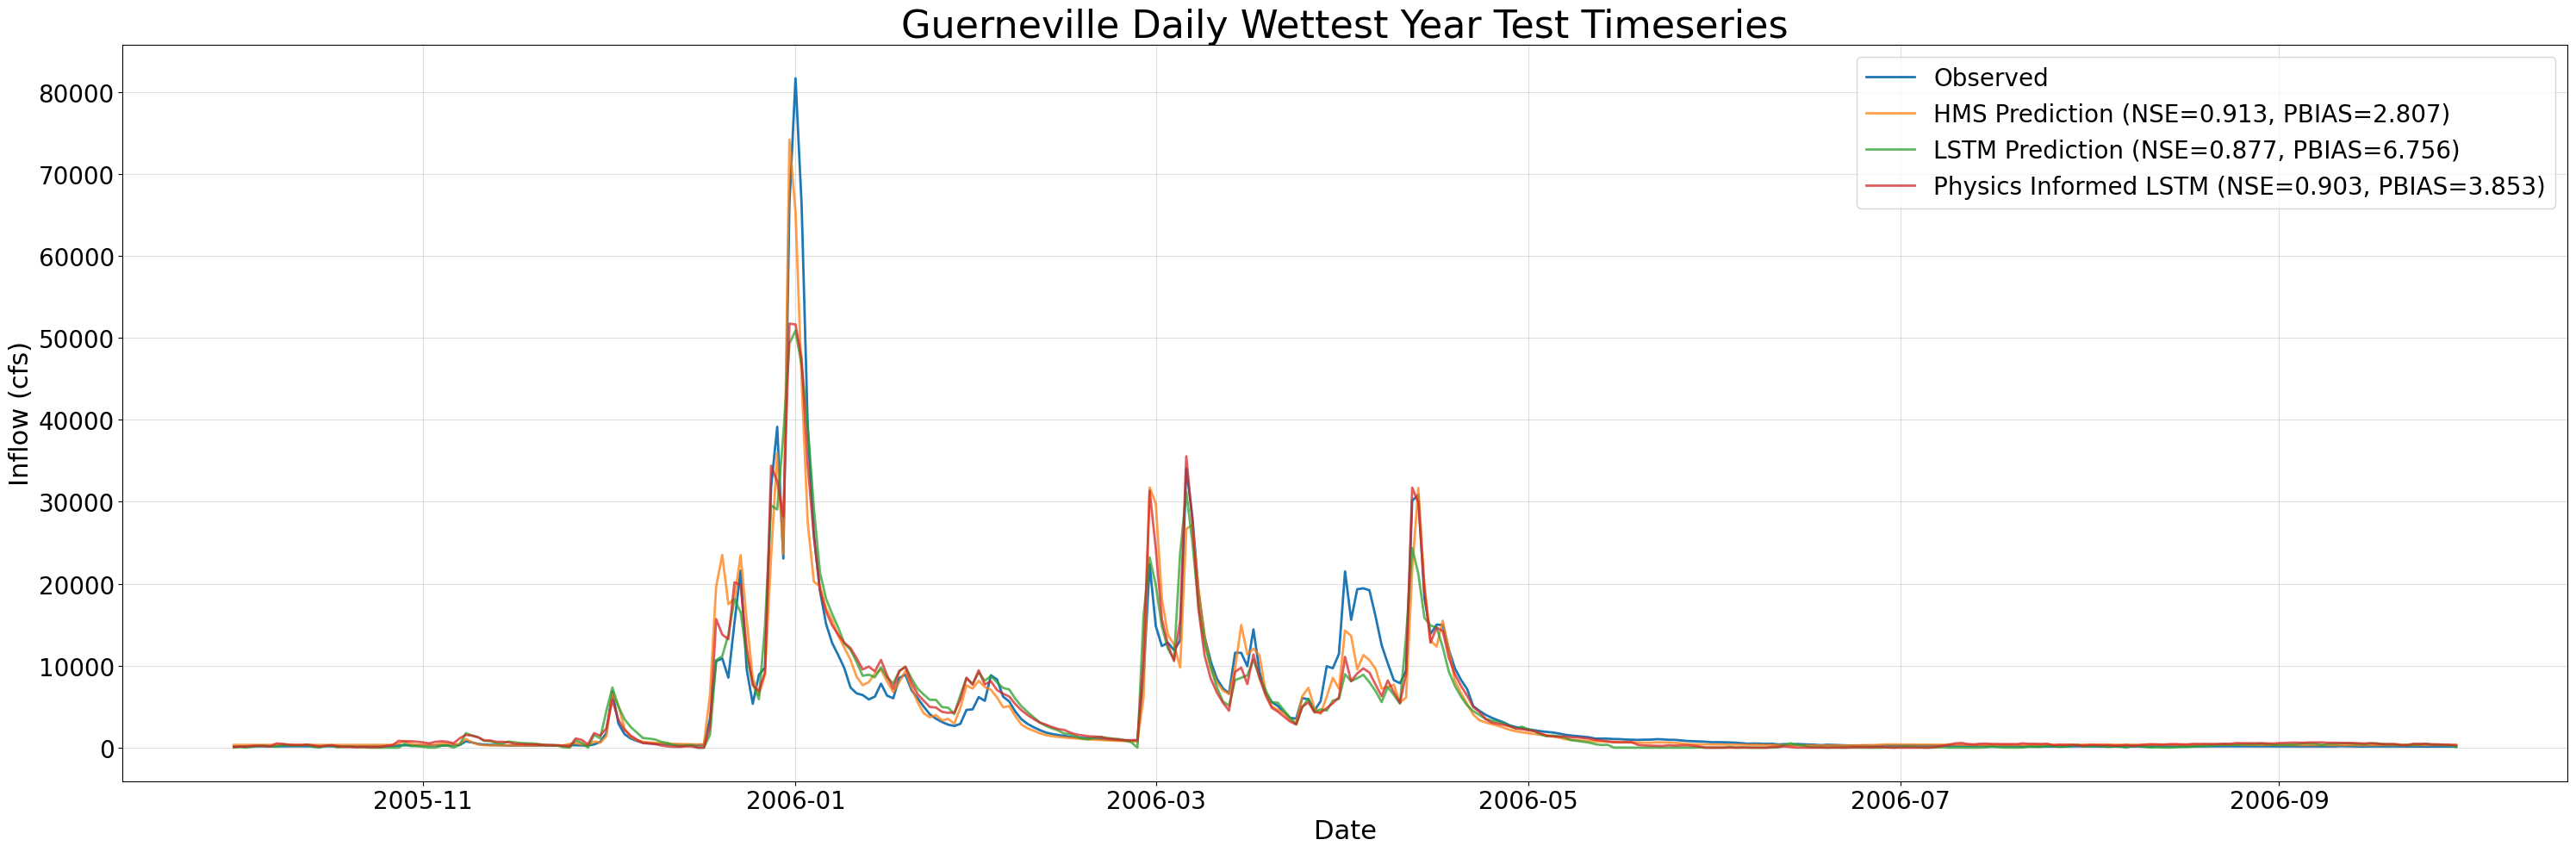

In [34]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Guerneville Daily Wettest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="guerneville_daily_test_wet_metrics.csv", ts_out="guerneville_daily_test_wet_combined_ts.csv", fig_out="guerneville_daily_test_wet_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Guerneville Daily Wettest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="guerneville_daily_test_wet_metrics.csv", ts_out="guerneville_daily_test_wet_combined_ts.csv", fig_out="guerneville_daily_test_wet_model_comparison.png", legend_font=20, axis_font=22)

In [35]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Guerneville Daily Wettest Year Test Timeseries – Interactive", backend="plotly", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="guerneville_daily_test_wet_metrics.csv", ts_out="guerneville_daily_test_wet_combined_ts.csv", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Guerneville Daily Wettest Year Test Timeseries – Interactive", backend="plotly", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="guerneville_daily_test_wet_metrics.csv", ts_out="guerneville_daily_test_wet_combined_ts.csv", legend_font=12, axis_font=22)

HMS
  NSE = 0.913
  PBIAS = 2.807
LSTM
  NSE = 0.877
  PBIAS = 6.756
PILSTM
  NSE = 0.903
  PBIAS = 3.853


##### Dryest Year Performance

HMS
  NSE = 0.729
  PBIAS = -8.618
LSTM
  NSE = 0.807
  PBIAS = 10.650
PILSTM
  NSE = 0.890
  PBIAS = -2.947


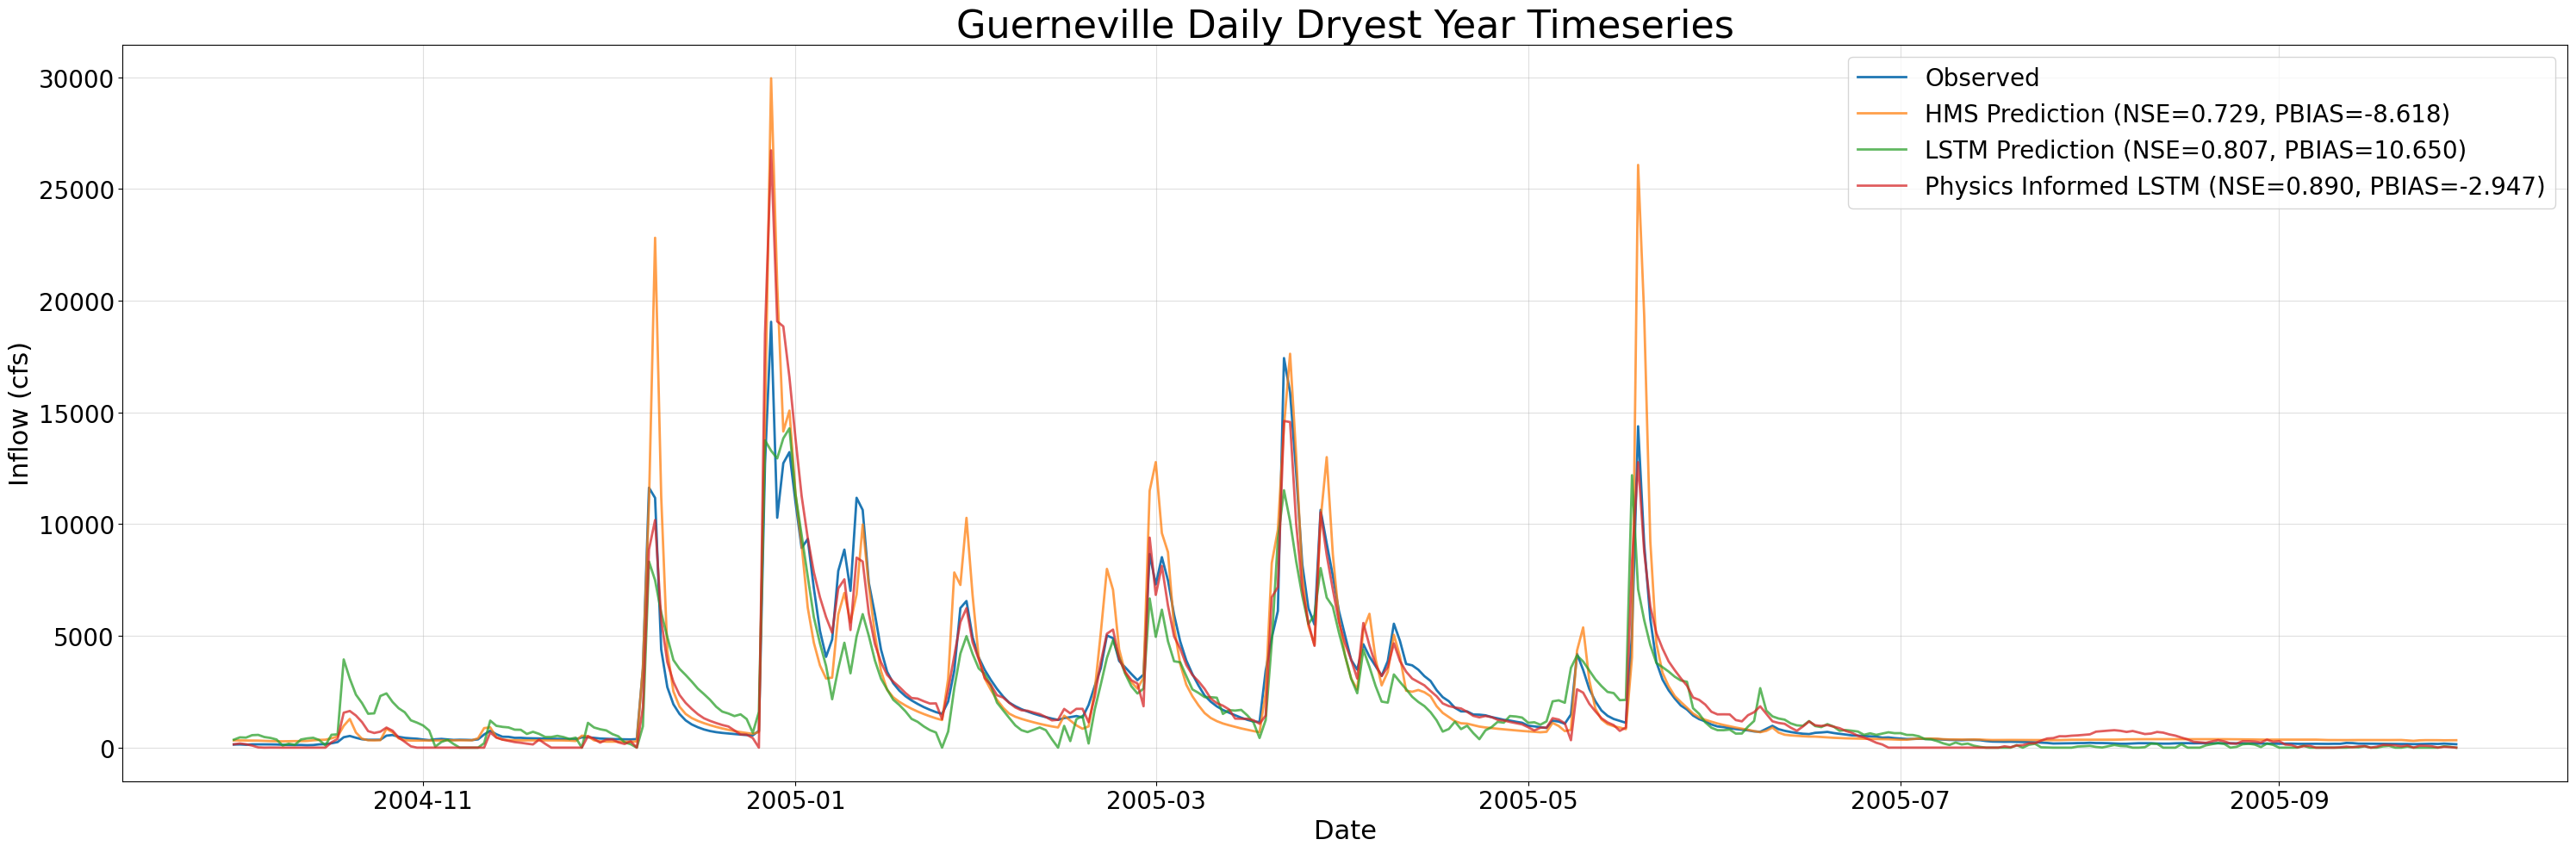

In [36]:
if not skip_best_model_validation:
    plot_timeseries_comparison(source=(no_physics_val_csv, physics_val_csv, path_to_physics_data), title="Guerneville Daily Dryest Year Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_val, end_date=dryest_end_val, metrics_out="guerneville_daily_val_dry_metrics.csv", ts_out="guerneville_daily_val_dry_combined_ts.csv", fig_out="guerneville_daily_val_dry_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_val, title="Guerneville Daily Dryest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_val, end_date=dryest_end_val, metrics_out="guerneville_daily_val_dry_metrics.csv", ts_out="guerneville_daily_val_dry_combined_ts.csv", fig_out="guerneville_daily_val_dry_model_comparison.png", legend_font=20, axis_font=22)

HMS
  NSE = 0.523
  PBIAS = -64.185
LSTM
  NSE = 0.681
  PBIAS = -60.332
PILSTM
  NSE = 0.711
  PBIAS = -43.312


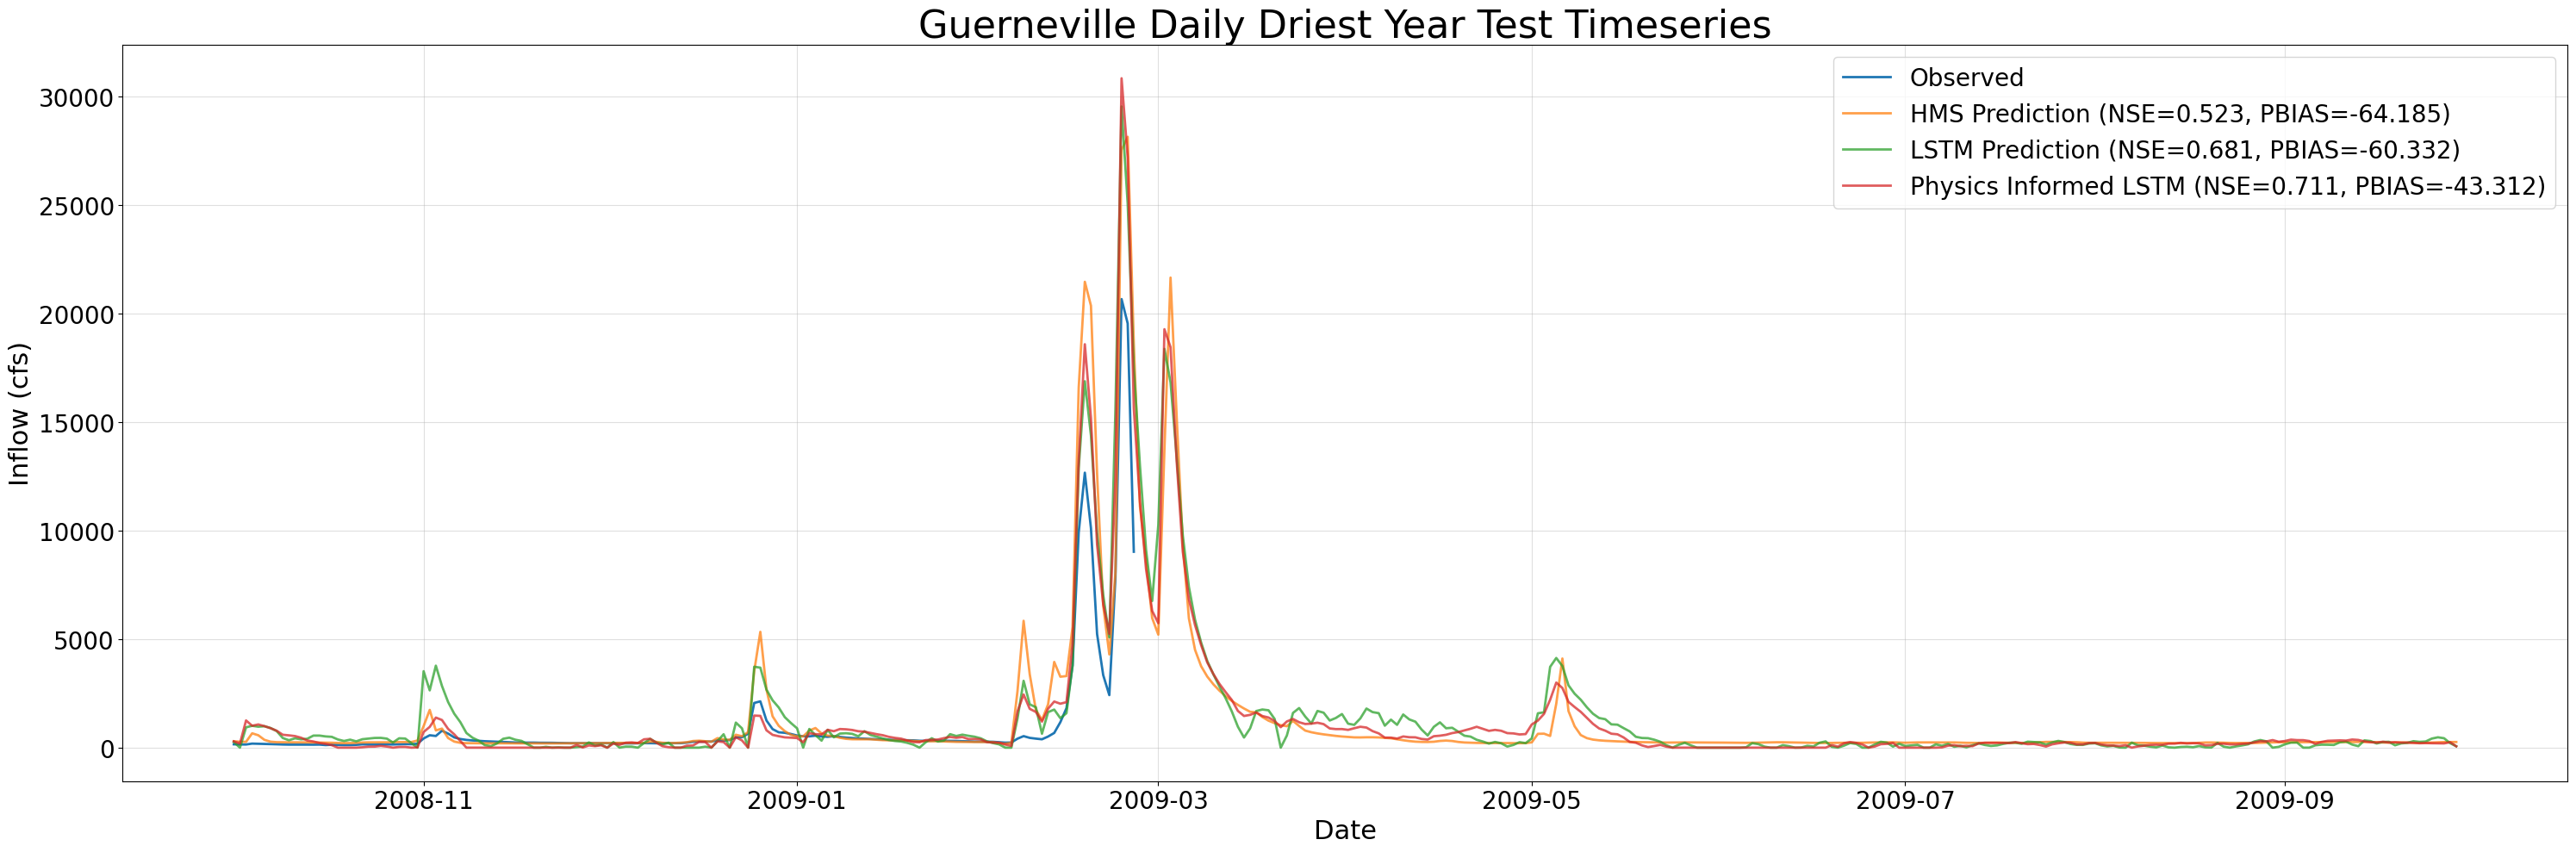

In [37]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Guerneville Daily Driest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="guerneville_daily_test_dry_metrics.csv", ts_out="guerneville_daily_test_dry_combined_ts.csv", fig_out="guerneville_daily_test_dry_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Guerneville Daily Driest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="guerneville_daily_test_dry_metrics.csv", ts_out="guerneville_daily_test_dry_combined_ts.csv", fig_out="guerneville_daily_test_dry_model_comparison.png", legend_font=20, axis_font=22)

In [38]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv, physics_test_csv, path_to_physics_data), title="Guerneville Daily Driest Year Test Timeseries – Interactive", backend="plotly", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="guerneville_daily_test_dry_metrics.csv", ts_out="guerneville_daily_test_dry_combined_ts.csv", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df, title="Guerneville Daily Driest Year Test Timeseries – Interactive", backend="plotly", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="guerneville_daily_test_dry_metrics.csv", ts_out="guerneville_daily_test_dry_combined_ts.csv", legend_font=12, axis_font=22)

HMS
  NSE = 0.523
  PBIAS = -64.185
LSTM
  NSE = 0.681
  PBIAS = -60.332
PILSTM
  NSE = 0.711
  PBIAS = -43.312


##### Gridded Timeseries Plots - Validation & Test

In [39]:
if not skip_best_model_validation:
    ts_triptych_v3((no_physics_val_csv, physics_val_csv, path_to_physics_data),wet_start=wettest_start_val, wet_end=wettest_end_val, dry_start=dryest_start_val, dry_end=dryest_end_val, save_path="guerneville_daily_TS_validation.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d-%b-%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title="Guerneville Daily Validation Period Timeseries Across Models", main_title_font=14, main_title_y=0.99, main_title_pad=0.05, row_titles=("Full Validation period","Most-wet water-year","Most-dry water-year"))

else:
    ts_triptych_v3(combined_df_val, wet_start=wettest_start_val, wet_end=wettest_end_val, dry_start=dryest_start_val, dry_end=dryest_end_val, save_path="guerneville_daily_TS_validation.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d‑%b‑%Y", figsize=(10, 10), dpi=600, hspace=0.2,main_title = "Guerneville Daily Validation Timeseries Across Models", main_title_font=14, main_title_y = 0.99, main_title_pad = 0.05, row_titles=("Full validation period", "Most‑wet water‑year", "Most‑dry water‑year"))

In [40]:
if not skip_best_model_test:
    ts_triptych_v3((no_physics_test_csv, physics_test_csv, path_to_physics_data), wet_start=wettest_start_test, wet_end=wettest_end_test,dry_start=dryest_start_test, dry_end=dryest_end_test, save_path="guerneville_daily_TS_testing.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d-%b-%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title="Guerneville Daily Test Period Timeseries Across Models", main_title_font=14, main_title_y=0.99, main_title_pad=0.05, row_titles=("Full Testing period","Most-wet water-year","Most-dry water-year"))

else:
    ts_triptych_v3(combined_df, wet_start=wettest_start_test, wet_end=wettest_end_test, dry_start=dryest_start_test, dry_end=dryest_end_test, save_path="guerneville_daily_TS_testing.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d‑%b‑%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title = "Guerneville Daily Test Period Timeseries Across Models", main_title_font=14, main_title_y = 0.99, main_title_pad = 0.05, row_titles=("Full Testing period", "Most‑wet water‑year", "Most‑dry water‑year"))

##### Gridded Scatterplots - Test

In [41]:
if not skip_best_model_test:
    scatter_triptych_pngs_v3((no_physics_test_csv, physics_test_csv, path_to_physics_data), wet_start=wettest_start_test, wet_end=wettest_end_test, dry_start=dryest_start_test, dry_end=dryest_end_test, out_dir="guerneville_daily_scatter", layout="horizontal", square_side=4.5, legend_font=16, axis_font=16, point_size=28, top_pad=.90, suptitle_y=1.04, dpi=600, row_titles=("Guerneville Daily – Full test period", "Guerneville Daily – Wettest water-year", "Guerneville Daily – Driest water-year"), resolution="daily")
else:
    scatter_pngs = scatter_triptych_pngs_v3(combined_df, wet_start = wettest_start_test, wet_end = wettest_end_test, dry_start = dryest_start_test,  dry_end = dryest_end_test, out_dir = "guerneville_daily_scatter", layout = "horizontal", square_side  = 4.5, legend_font  = 16, axis_font = 16, point_size = 28, top_pad = .90, suptitle_y = 1.04, dpi = 600, row_titles = ("Guerneville Daily – Full test period", "Guerneville Daily – Wettest water‑year", "Guerneville Daily – Driest water‑year"), resolution = "daily")